In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

COLS = (
    ["unit_id", "cycle"] +
    [f"op_{i}" for i in range(1, 4)] +
    [f"s{i}" for i in range(1, 22)]
)

df = pd.read_csv("D:\\repo\\predictive-maintenance-lstm\\data\\raw\\train_FD001.txt", sep=r"\s+", header=None, names=COLS)


Min cycles: 128  Max: 362  Mean: 206


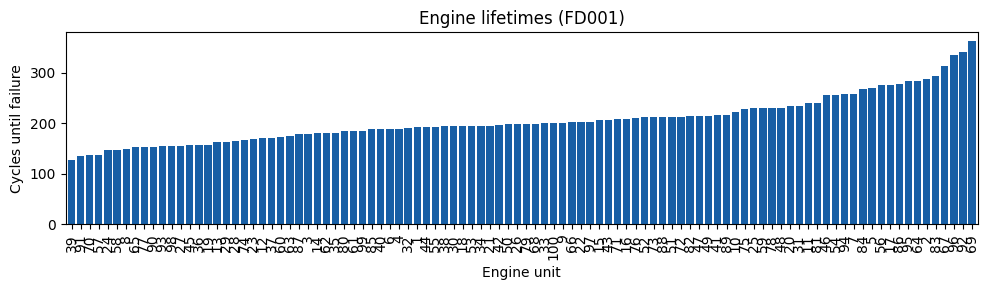

In [5]:
max_cycles = df.groupby("unit_id")["cycle"].max()
print(f"Min cycles: {max_cycles.min()}  Max: {max_cycles.max()}  Mean: {max_cycles.mean():.0f}")

plt.figure(figsize=(10, 3))
max_cycles.sort_values().plot(kind="bar", color="#185FA5", width=0.8)
plt.title("Engine lifetimes (FD001)")
plt.xlabel("Engine unit"); plt.ylabel("Cycles until failure")
plt.tight_layout(); plt.savefig("engine_lifetimes.png", dpi=150); plt.show()


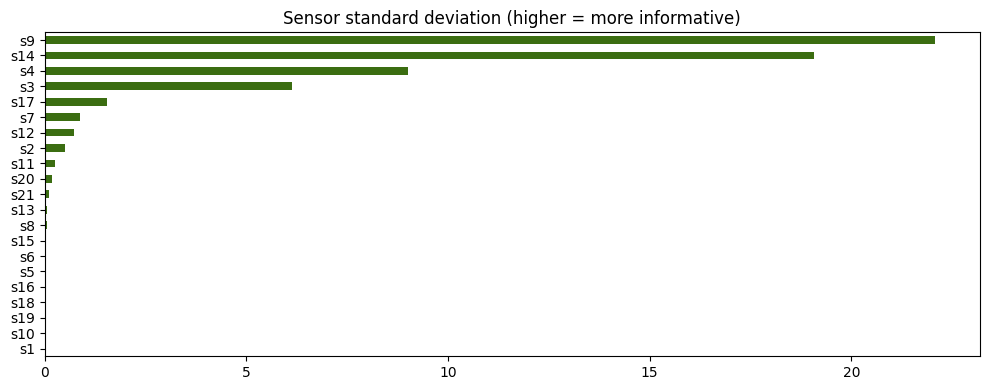


Flat (useless) sensors: ['s1', 's10', 's19', 's18', 's16', 's5', 's6']


In [7]:
# ── 2. Sensor variance — which sensors actually change? ───────────────────────
sensor_cols = [f"s{i}" for i in range(1, 22)]
sensor_std = df[sensor_cols].std().sort_values()

plt.figure(figsize=(10, 4))
sensor_std.plot(kind="barh", color="#3B6D11")
plt.title("Sensor standard deviation (higher = more informative)")
plt.tight_layout(); plt.savefig("sensor_variance.png", dpi=150); plt.show()

# Sensors with near-zero std are useless — identify them
flat_sensors = sensor_std[sensor_std < 0.01].index.tolist()
print(f"\nFlat (useless) sensors: {flat_sensors}")


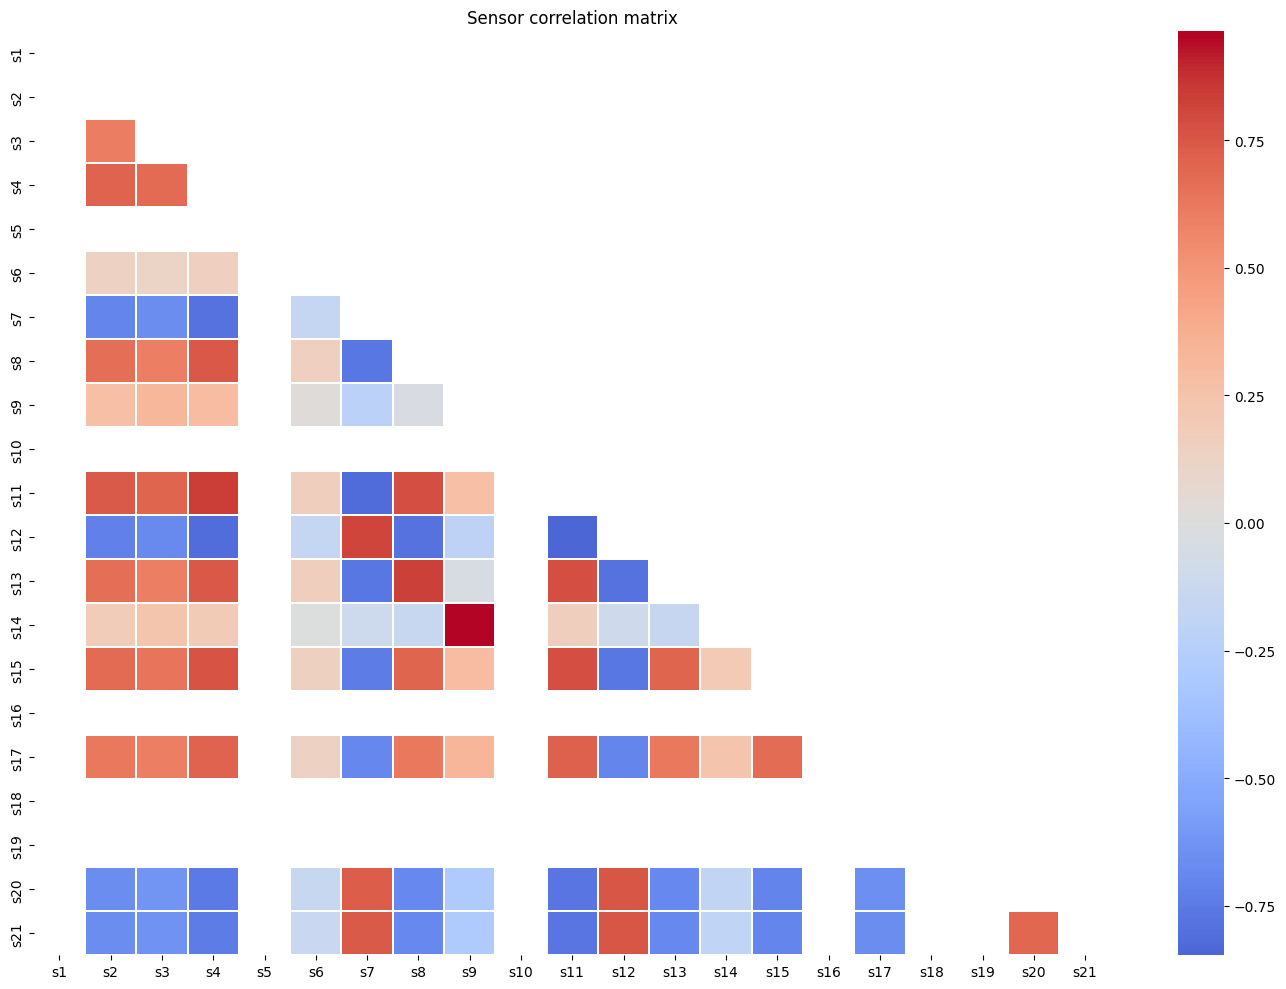

In [9]:
# ── 4. Correlation heatmap ────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
corr = df[sensor_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3)
plt.title("Sensor correlation matrix")
plt.tight_layout(); plt.savefig("sensor_correlation.png", dpi=150); plt.show()